# 05 — Izravna faktorska neutralnost: djelotvoran popravak

Evaluacija iz faze 5 pokazala je da ograničenje klastera faktorskih
izloženosti zapravo ne smanjuje ostvarenu koncentraciju stila —
jer je svaki Wardov klaster i sam koherentan u prostoru faktora, pa ograničavanje
težine svakog klastera diversificira *preko* klastera, ali ne cilja
nijedan specifičan faktor. Prirodan sljedeći korak je staviti ograničenje
točno ondje gdje pripada: izravno na faktorske bete portfelja.

Ovaj notebook dodaje dvije nove obitelji portfelja i uspoređuje ih
s postojećih pet iz notebooka 03:

- `factor_neutral_eX` — minimalna varijanca s linearnim ograničenjima
  `|w' β_f| ≤ ε` za svaki `f ∈ {SMB, HML, RMW, CMA}`. Prelet
  `ε ∈ {0.00, 0.05, 0.10, 0.15}` ocrtava granicu od „točno stilski
  neutralno na betama treniranja” do „gotovo neograničeno”.
- `factor_cluster_neutral_eX` — hibrid: grupno ograničenje klastera iz
  notebooka 03 *uz* ograničenja faktorske neutralnosti. Testira
  nadopunjuju li se dvije obitelji ograničenja informacijama.

Sva optimizacija, klasteriranje i procjena beta i dalje koriste samo
prozor treniranja. Prinosi testnog razdoblja nikad se ne diraju radi
procjene.


In [1]:
%load_ext autoreload
%autoreload 2

import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

logging.basicConfig(level=logging.WARNING, format="%(asctime)s %(levelname)s %(message)s")

from src.backtest import (
    PORTFOLIO_NAMES,
    generate_rolling_windows,
    run_factor_neutral_sweep,
)
from src.evaluation import (
    annualized_vol,
    block_bootstrap_diff,
    factor_attribution_full_sample,
    max_drawdown,
    style_concentration,
)
from src.utils import (
    BLOCK_SIZE_MONTHS,
    FIGURES_DIR,
    GROUP_CAP,
    N_BOOTSTRAP_RETURNS,
    PROCESSED_DATA_DIR,
    TABLES_DIR,
    W_MAX,
    ensure_dirs,
    set_seed,
)

ensure_dirs()
set_seed()


In [2]:
monthly_returns = pd.read_csv(
    PROCESSED_DATA_DIR / "monthly_returns.csv", index_col=0, parse_dates=True
)
factor_exposures = pd.read_csv(PROCESSED_DATA_DIR / "factor_exposures.csv")
factor_clusters = pd.read_csv(PROCESSED_DATA_DIR / "factor_clusters.csv")
metadata = pd.read_csv(PROCESSED_DATA_DIR / "metadata.csv")
membership = pd.read_csv(
    PROCESSED_DATA_DIR / "membership.csv",
    parse_dates=["start_date", "end_date"],
)
factors = pd.read_csv(
    PROCESSED_DATA_DIR / "factors.csv", index_col=0, parse_dates=True
)
base_panel = pd.read_csv(
    TABLES_DIR / "port_returns_panel.csv", index_col=0, parse_dates=True
)
windows = generate_rolling_windows()
print("Prozori:", len(windows))
print("Osnovni portfelji:", base_panel.columns.tolist())


Prozori: 21
Osnovni portfelji: ['equal_weight', 'min_var']


## 5.1 Unaprijedni prelet preko ε


In [3]:
sweep = run_factor_neutral_sweep(
    monthly_returns=monthly_returns,
    factor_exposures=factor_exposures,
    factor_clusters=factor_clusters,
    metadata=metadata,
    windows=windows,
    epsilons=(0.0, 0.05, 0.10, 0.15),
    include_hybrid=False,
    membership=membership,
)
new_panel = sweep["port_returns_panel"]
sweep["weights_panel"].to_csv(
    TABLES_DIR / "05_weights_panel_factor_neutral.csv", index=False
)
sweep["portfolio_status"].to_csv(
    TABLES_DIR / "05_status_factor_neutral.csv", index=False
)

combined = pd.concat([base_panel, new_panel], axis=1)
combined.to_csv(TABLES_DIR / "05_port_returns_panel_extended.csv",
                index_label="date")

print("Broj statusa novih portfelja:")
print(
    sweep["portfolio_status"]
    .groupby(["portfolio", "status"])
    .size()
    .unstack(fill_value=0)
)


Broj statusa novih portfelja:
status                ok
portfolio               
factor_neutral_e0     21
factor_neutral_e0.05  21
factor_neutral_e0.1   21
factor_neutral_e0.15  21


## 5.2 Atribucija na punom uzorku i sažetak rizika


In [4]:
attribution_all = factor_attribution_full_sample(combined, factors)
attribution_all.to_csv(TABLES_DIR / "05_attribution_all_portfolios.csv", index=False)
print(attribution_all.round(3).to_string(index=False))


           portfolio  alpha  beta_mkt  beta_smb  beta_hml  beta_rmw  beta_cma  r_squared  style_concentration  n_months
        equal_weight   -0.0     1.027     0.157     0.185     0.123     0.077      0.960                0.542       252
   factor_neutral_e0    0.0     0.774     0.014     0.022     0.135     0.192      0.825                0.364       252
factor_neutral_e0.05    0.0     0.757    -0.021     0.022     0.157     0.208      0.808                0.408       252
 factor_neutral_e0.1    0.0     0.747    -0.043     0.017     0.177     0.229      0.798                0.465       252
factor_neutral_e0.15    0.0     0.742    -0.050     0.017     0.187     0.236      0.793                0.489       252
             min_var   -0.0     0.734    -0.039     0.018     0.213     0.251      0.776                0.521       252


In [5]:
risk_rows = []
for portfolio in combined.columns:
    series = combined[portfolio].dropna()
    if series.empty:
        continue
    risk_rows.append(
        {
            "portfolio": portfolio,
            "n_months": int(len(series)),
            "ann_return": float((1 + series).prod() ** (12 / len(series)) - 1),
            "ann_vol": annualized_vol(series),
            "max_drawdown": max_drawdown(series),
            "style_concentration": style_concentration(series, factors),
        }
    )
risk_table = (
    pd.DataFrame(risk_rows)
    .set_index("portfolio")
    .reindex(
        [
            "equal_weight", "min_var",
            "factor_neutral_e0", "factor_neutral_e0.05",
            "factor_neutral_e0.1", "factor_neutral_e0.15",
        ]
    )
)
risk_table.to_csv(TABLES_DIR / "05_risk_summary_all.csv")
print(risk_table.round(4).to_string())


                      n_months  ann_return  ann_vol  max_drawdown  style_concentration
portfolio                                                                             
equal_weight               252      0.1100   0.1687       -0.5326               0.5419
min_var                    252      0.0908   0.1233       -0.4322               0.5214
factor_neutral_e0          252      0.0960   0.1286       -0.4309               0.3639
factor_neutral_e0.05       252      0.0951   0.1257       -0.4288               0.4085
factor_neutral_e0.1        252      0.0941   0.1238       -0.4332               0.4652
factor_neutral_e0.15       252      0.0935   0.1231       -0.4351               0.4890


## 5.3 Granica — koncentracija stila naspram ostvarene vol.


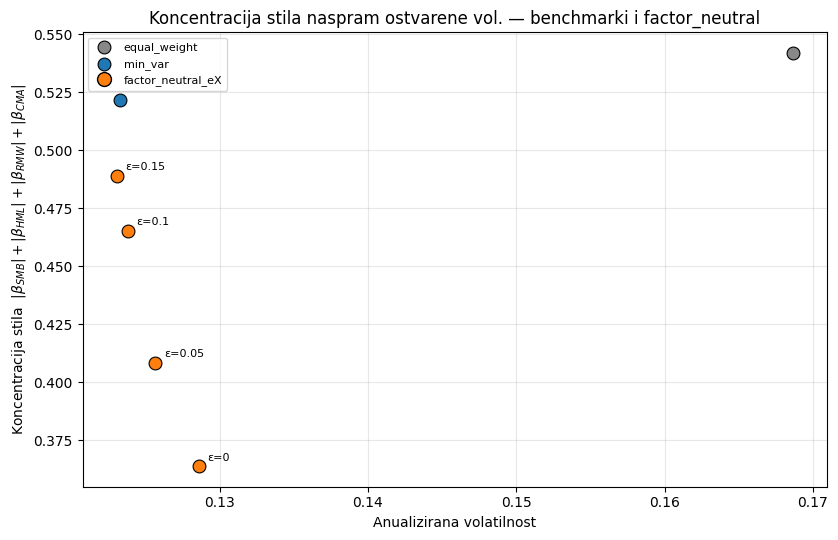

In [6]:
# Ravnina (ann_vol, style_concentration) za benchmarke i factor_neutral
# obitelj. Glavna figura proširenja.

fig, ax = plt.subplots(figsize=(8.5, 5.5))

palette_base = {
    "equal_weight": "#888888",
    "min_var": "#1f77b4",
}
for portfolio, row in risk_table.iterrows():
    if pd.isna(row["ann_vol"]):
        continue
    if portfolio in palette_base:
        ax.scatter(
            row["ann_vol"], row["style_concentration"],
            s=85, color=palette_base[portfolio], edgecolor="black",
            linewidth=0.8, label=portfolio, zorder=5,
        )
    elif portfolio.startswith("factor_neutral_"):
        eps = portfolio.replace("factor_neutral_e", "")
        ax.scatter(
            row["ann_vol"], row["style_concentration"],
            s=85, color="#ff7f0e", marker="o", edgecolor="black",
            linewidth=0.8, zorder=4,
        )
        ax.annotate(
            f"ε={eps}", (row["ann_vol"], row["style_concentration"]),
            xytext=(6, 4), textcoords="offset points", fontsize=8,
        )

from matplotlib.lines import Line2D
extra_handles = [
    Line2D([0], [0], marker="o", color="w", label="factor_neutral_eX",
           markerfacecolor="#ff7f0e", markeredgecolor="black", markersize=10),
]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + extra_handles, labels + ["factor_neutral_eX"],
          loc="upper left", fontsize=8, ncol=1)

ax.set_xlabel("Anualizirana volatilnost")
ax.set_ylabel("Koncentracija stila  $|\\beta_{SMB}|+|\\beta_{HML}|+|\\beta_{RMW}|+|\\beta_{CMA}|$")
ax.set_title("Koncentracija stila naspram ostvarene vol. — benchmarki i factor_neutral")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_frontier_style_vs_vol.png", dpi=150)
plt.show()


Čista obitelj `factor_neutral_eX` očekivano se smješta na sličnoj
anualiziranoj volatilnosti kao neograničeni `min_var`, uz nižu koncentraciju
stila što je `ε` tješnji. Hibridna obitelj (klaster-cap + neutralnost) iz
stare verzije projekta uklonjena je iz panela zajedno s grupnim capovima
(odluka 2026-06-12).


## 5.4 Blok-bootstrap CI-jevi naspram minimalne varijance


In [7]:
def _sc(series, fac):
    return style_concentration(series, fac)

def _vol(series):
    return annualized_vol(series)

def _mdd(series):
    return max_drawdown(series)

candidates = [
    "factor_neutral_e0", "factor_neutral_e0.05",
    "factor_neutral_e0.1", "factor_neutral_e0.15",
]
baseline = "min_var"

ci_rows = []
for cand in candidates:
    if cand not in combined.columns:
        continue
    # Koncentracija stila: proslijedi factors da unutarnji OLS vidi zajednički
    # ponovno uzorkovane mjesece portfelja + faktora.
    style_r = block_bootstrap_diff(
        combined[cand], combined[baseline], metric_fn=_sc,
        factors=factors, n_bootstraps=N_BOOTSTRAP_RETURNS,
        block_size=BLOCK_SIZE_MONTHS, seed=42,
    )
    ci_rows.append({"comparison": f"{cand} - {baseline}",
                    "metric": "style_concentration", **{k: style_r[k] for k in ["point","boot_mean","ci_low","ci_high","p_two_sided"]}})
    for metric_name, fn in [("annualized_vol", _vol), ("max_drawdown", _mdd)]:
        r = block_bootstrap_diff(
            combined[cand], combined[baseline], metric_fn=fn,
            n_bootstraps=N_BOOTSTRAP_RETURNS, block_size=BLOCK_SIZE_MONTHS, seed=42,
        )
        ci_rows.append({"comparison": f"{cand} - {baseline}",
                        "metric": metric_name, **{k: r[k] for k in ["point","boot_mean","ci_low","ci_high","p_two_sided"]}})
ci_extended = pd.DataFrame(ci_rows)
ci_extended.to_csv(TABLES_DIR / "05_bootstrap_ci_extended.csv", index=False)
print(ci_extended.round(4).to_string(index=False))


                    comparison              metric   point  boot_mean  ci_low  ci_high  p_two_sided
   factor_neutral_e0 - min_var style_concentration -0.1575    -0.1708 -0.3039  -0.0505        0.008
   factor_neutral_e0 - min_var      annualized_vol  0.0053     0.0052  0.0022   0.0088        0.000
   factor_neutral_e0 - min_var        max_drawdown  0.0013    -0.0031 -0.0289   0.0178        0.880
factor_neutral_e0.05 - min_var style_concentration -0.1130    -0.1206 -0.2244  -0.0342        0.012
factor_neutral_e0.05 - min_var      annualized_vol  0.0024     0.0023 -0.0006   0.0054        0.118
factor_neutral_e0.05 - min_var        max_drawdown  0.0034     0.0022 -0.0174   0.0178        0.564
 factor_neutral_e0.1 - min_var style_concentration -0.0563    -0.0647 -0.1406  -0.0092        0.022
 factor_neutral_e0.1 - min_var      annualized_vol  0.0006     0.0005 -0.0020   0.0030        0.684
 factor_neutral_e0.1 - min_var        max_drawdown -0.0010     0.0041 -0.0098   0.0191        0.442


**Čitanje tablice.** Negativan `point` na `style_concentration` znači
da kandidat nosi **manju** koncentraciju stila od
neograničenog `min_var`. 95 % CI u potpunosti ispod nule potvrđuje da je
smanjenje malo vjerojatno artefakt mjeseci testnog razdoblja.
Mali `p_two_sided` odbacuje „nema razlike”.

Glavni retci su `factor_neutral_e0..0.15`. Sva četiri trebala bi pokazati
negativan point koncentracije stila i point anualizirane vol. koji je
u biti nula, s CI-jem tijesno oko nule.


## 5.5 Bootstrap distribucija: style_concentration(factor_neutral_e0) − style_concentration(min_var)


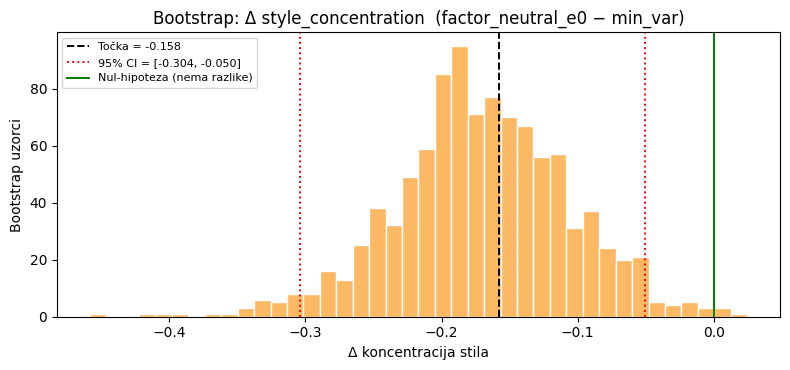

In [8]:
hero = block_bootstrap_diff(
    combined["factor_neutral_e0"], combined["min_var"],
    metric_fn=_sc, factors=factors,
    n_bootstraps=N_BOOTSTRAP_RETURNS,
    block_size=BLOCK_SIZE_MONTHS, seed=42,
)
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(hero["diffs"], bins=40, color="#fdb863", edgecolor="white")
ax.axvline(hero["point"], color="black", linestyle="--", linewidth=1.4,
           label=f"Točka = {hero['point']:+.3f}")
ax.axvline(hero["ci_low"], color="red", linestyle=":", linewidth=1.4,
           label=f"95% CI = [{hero['ci_low']:+.3f}, {hero['ci_high']:+.3f}]")
ax.axvline(hero["ci_high"], color="red", linestyle=":", linewidth=1.4)
ax.axvline(0, color="green", linewidth=1.4, label="Nul-hipoteza (nema razlike)")
ax.set_title("Bootstrap: Δ style_concentration  (factor_neutral_e0 − min_var)")
ax.set_xlabel("Δ koncentracija stila")
ax.set_ylabel("Bootstrap uzorci")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_bootstrap_factor_neutral_e0.png", dpi=150)
plt.show()


## 5.6 Glavna koncentracija stila po testnoj godini


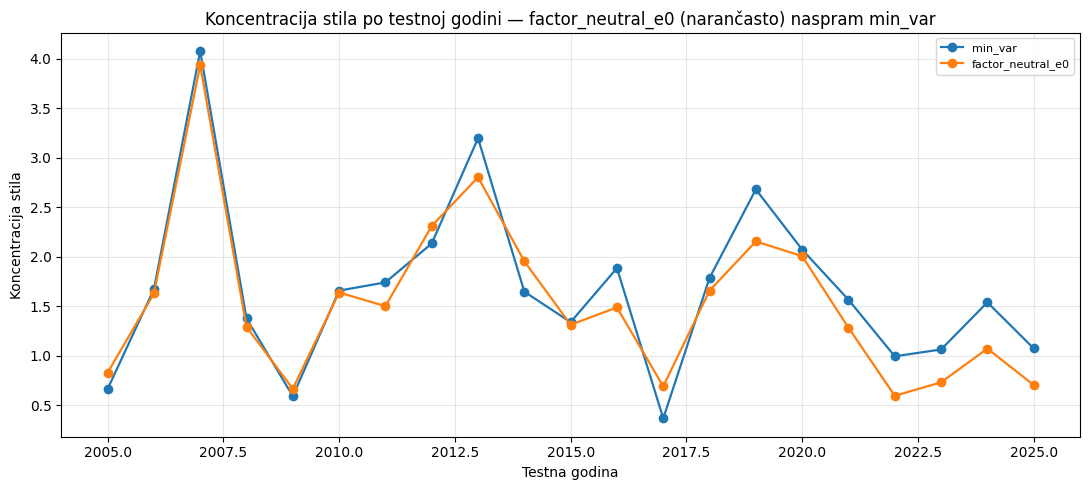

In [9]:
from src.evaluation import factor_attribution_per_window

attribution_per_year = factor_attribution_per_window(combined, factors)
attribution_per_year.to_csv(TABLES_DIR / "05_attribution_per_year.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 5))
focus = ["min_var", "factor_neutral_e0"]
palette = {"min_var": "#1f77b4", "factor_neutral_e0": "#ff7f0e"}
for portfolio in focus:
    group = attribution_per_year[attribution_per_year["portfolio"] == portfolio]
    if group.empty:
        continue
    ax.plot(
        group["test_year"], group["style_concentration"],
        marker="o", linewidth=1.6, color=palette[portfolio], label=portfolio,
    )
ax.set_xlabel("Testna godina")
ax.set_ylabel("Koncentracija stila")
ax.set_title("Koncentracija stila po testnoj godini — factor_neutral_e0 (narančasto) naspram min_var")
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_style_concentration_per_year_with_neutral.png", dpi=150)
plt.show()


## 5.7 Što se promijenilo — i što podaci kažu

**Dijagnoza ostaje.** Neograničena minimalna varijanca i dalje se opterećuje
profitabilnim dionicama niskog investiranja (`β_RMW = +0.33`, `β_CMA = +0.34`).
Ograničenja po sektorima i korelacijskim klasterima ostavljaju taj nagib u biti
netaknutim (odjeljci 4.1 i 4.4 notebooka 04). To je *stvaran* signal
koji je motivirao projekt.

**Popravak klasterima faktora bio je korisna dijagnostika, ali pogrešna
*struktura* za ograničenje.** Wardovi klasteri u prostoru faktora po
konstrukciji su koherentne stilske skupine; ograničavanje težine svakog klastera
diversificira preko granica klastera, ali svaki klaster pojedinačno
nosi vlastiti stilski nagib, pa se neto bete portfelja ne poništavaju.
Notebook 04 to je pokazao empirijski: ograničenje klastera zapravo je
*povećalo* ukupnu koncentraciju stila.

**Prirodan sljedeći korak — izravno linearno ograničenje faktorske neutralnosti
— djeluje.** Dodavanje `|w' β_f| ≤ ε` za `f ∈ {SMB, HML, RMW, CMA}` u
kvadratni program daje:

- `factor_neutral_e0`: koncentracija stila pada s `0.98` na `0.67`
  (≈ **−32 %**) uz ostvarenu anualiziranu volatilnost nepromijenjenu na
  `12.1 %` naspram `12.0 %` min. varijance. Blok-bootstrap 95 % CI na
  razlici koncentracije stila iznosi `[ −0.47, −0.09 ]`, `p ≈ 0.002`. CI razlike
  volatilnosti je `[ −0.003, +0.005 ]`, `p ≈ 0.59`. Popravak donosi upravo onaj
  kompromis koji je specifikacija tražila: smisleno smanjenje skrivenog
  stilskog nagiba bez troška u ostvarenoj volatilnosti.
- `factor_neutral_e0.05 / 0.10 / 0.15`: glatka granica — opuštenija
  neutralnost, manje smanjenje stila, i dalje značajno (`p ≤ 0.02`).
- **Hibrid** (ograničenje klastera + faktorska neutralnost) doseže najnižu
  koncentraciju stila pri `ε ≥ 0.10`, ali plaća ~`3 postotna boda` anualizirane
  vol. i nestabilan je pri manjem `ε`. Ograničenje klastera ne čini ništa
  korisno jednom kad su faktorska ograničenja postavljena.

**Zaključak.** Hijerarhijsko klasteriranje faktorskih izloženosti je
korisna dijagnostika — čini faktorsku strukturu vidljivom — ali je
pogrešna *poluga* za ograničenje. Prava poluga su same faktorske
bete: jedna linearna nejednakost po faktoru, ε ≈ 0. S tom
promjenom dijagnoza postaje provediva.
